In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import seaborn as sns
from sklearn.metrics import r2_score, explained_variance_score, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
db = pd.read_csv("Groundwater.csv")

In [3]:
db.head()

,States,Recharge from rainfallMonsoon season,Recharge from other sources,Recharge from rainfallNon-monsoon season,Recharge from other sources.1,Total_Rainfall,Natural discharge during non-monsoon season,Net annual groundwater availability,Irrigation,Domestic and industrial uses,Total_Usage,Projected demand for domestic and industrial uses upto 2025,Groundwater availability for future irrigation use,Situation
0,Andhra Pradesh,15.1,6.5000,5.5,6.7000,33.8,3.1,30.8,12.600,1.500,14.200,2.70,15.9,EXCESS
1,Arunachal Pradesh,3.4,0.0003,1.0,0.0004,4.5,0.5,4.0,0.002,0.001,0.003,0.01,4.0,SEMICRITICAL
2,Assam,19.0,2.2000,8.6,0.6000,30.4,2.5,27.8,5.300,0.700,6.000,1.00,21.5,EXCESS
3,Bihar,18.9,3.9000,3.4,2.4000,28.6,2.4,26.2,9.800,1.600,11.400,2.60,13.9,MODERATED
4,Chhattisgarh,9.9,0.6000,0.9,0.9000,12.2,0.6,11.6,3.100,0.500,3.600,0.60,7.9,MODERATED


,EXCESS,MODERATED,SEMICRITICAL
0,1,0,0
1,0,0,1
2,1,0,0
3,0,1,0
4,0,1,0


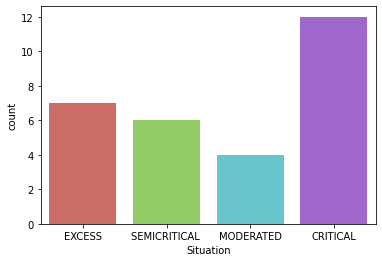

In [4]:
sb.countplot(x='Situation',data=db, palette='hls')
Availabilty = pd.get_dummies(db['Situation'],drop_first=True)
Availabilty.head()

In [5]:
val = pd.factorize(db['Situation'])[0]
db.drop(['Situation'],axis=1,inplace=True)
db['situation']=val
db.head()

,States,Recharge from rainfallMonsoon season,Recharge from other sources,Recharge from rainfallNon-monsoon season,Recharge from other sources.1,Total_Rainfall,Natural discharge during non-monsoon season,Net annual groundwater availability,Irrigation,Domestic and industrial uses,Total_Usage,Projected demand for domestic and industrial uses upto 2025,Groundwater availability for future irrigation use,situation
0,Andhra Pradesh,15.1,6.5000,5.5,6.7000,33.8,3.1,30.8,12.600,1.500,14.200,2.70,15.9,0
1,Arunachal Pradesh,3.4,0.0003,1.0,0.0004,4.5,0.5,4.0,0.002,0.001,0.003,0.01,4.0,1
2,Assam,19.0,2.2000,8.6,0.6000,30.4,2.5,27.8,5.300,0.700,6.000,1.00,21.5,0
3,Bihar,18.9,3.9000,3.4,2.4000,28.6,2.4,26.2,9.800,1.600,11.400,2.60,13.9,2
4,Chhattisgarh,9.9,0.6000,0.9,0.9000,12.2,0.6,11.6,3.100,0.500,3.600,0.60,7.9,2


In [6]:
new_data = pd.concat([db,Availabilty],axis=1)
new_data.head()

,States,Recharge from rainfallMonsoon season,Recharge from other sources,Recharge from rainfallNon-monsoon season,Recharge from other sources.1,Total_Rainfall,Natural discharge during non-monsoon season,Net annual groundwater availability,Irrigation,Domestic and industrial uses,Total_Usage,Projected demand for domestic and industrial uses upto 2025,Groundwater availability for future irrigation use,situation,EXCESS,MODERATED,SEMICRITICAL
0,Andhra Pradesh,15.1,6.5000,5.5,6.7000,33.8,3.1,30.8,12.600,1.500,14.200,2.70,15.9,0,1,0,0
1,Arunachal Pradesh,3.4,0.0003,1.0,0.0004,4.5,0.5,4.0,0.002,0.001,0.003,0.01,4.0,1,0,0,1
2,Assam,19.0,2.2000,8.6,0.6000,30.4,2.5,27.8,5.300,0.700,6.000,1.00,21.5,0,1,0,0
3,Bihar,18.9,3.9000,3.4,2.4000,28.6,2.4,26.2,9.800,1.600,11.400,2.60,13.9,2,0,1,0
4,Chhattisgarh,9.9,0.6000,0.9,0.9000,12.2,0.6,11.6,3.100,0.500,3.600,0.60,7.9,2,0,1,0


In [7]:
X=new_data.iloc[:,[5,6,7,10,11,12]].values
Y=new_data.iloc[:, 13].values

In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.55, random_state = 0)
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [9]:
db.describe()

,Recharge from rainfallMonsoon season,Recharge from other sources,Recharge from rainfallNon-monsoon season,Recharge from other sources.1,Total_Rainfall,Natural discharge during non-monsoon season,Net annual groundwater availability,Irrigation,Domestic and industrial uses,Total_Usage,Projected demand for domestic and industrial uses upto 2025,Groundwater availability for future irrigation use,situation
count,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000
mean,8.490690,2.328976,1.563793,2.474152,14.846207,1.210483,13.644483,7.631724,0.758021,8.392048,1.063483,5.292414,1.724138
std,9.909697,3.420270,2.139700,3.733489,16.931169,1.448532,15.538660,10.802838,0.798408,11.440317,1.172055,7.782267,1.250616
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.040000,0.000000,0.000200,0.000400,0.001000,-14.600000,0.000000
25%,1.000000,0.010000,0.200000,0.100000,1.200000,0.100000,1.100000,0.100000,0.030000,0.200000,0.100000,0.400000,1.000000
50%,4.800000,0.700000,0.800000,0.900000,10.500000,0.600000,9.800000,3.100000,0.700000,3.600000,0.800000,3.000000,2.000000
75%,12.200000,2.700000,1.900000,3.500000,22.900000,2.000000,20.700000,11.900000,1.100000,13.000000,1.700000,11.900000,3.000000
max,40.800000,11.400000,8.600000,17.700000,75.300000,6.700000,68.600000,46.000000,3.500000,49.500000,5.400000,21.500000,3.000000


<AxesSubplot:xlabel='EXCESS', ylabel='count'>

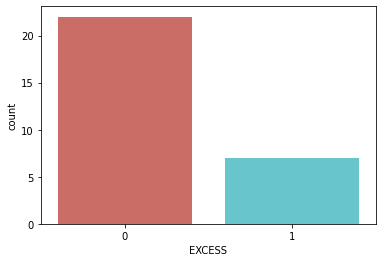

In [10]:
sb.countplot(x='EXCESS',data=new_data, palette='hls')


<AxesSubplot:xlabel='MODERATED', ylabel='count'>

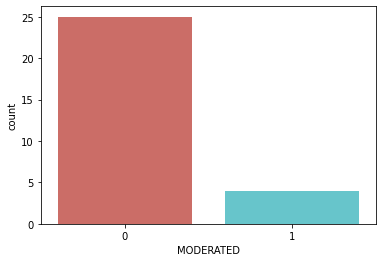

In [11]:
sb.countplot(x='MODERATED',data=new_data, palette='hls')

<AxesSubplot:>

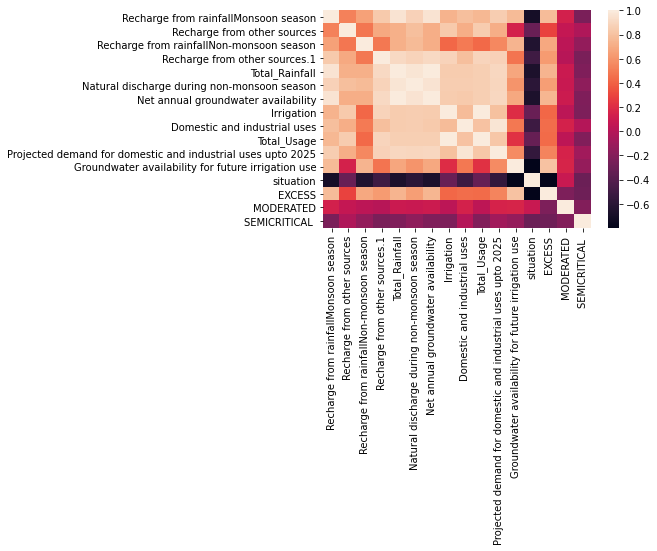

In [12]:
sb.heatmap(new_data.corr())

In [13]:
labels='Total Rainfall','Net Annual GroundWater','Total Use','Future Available','Projected demand for domestic and industrial uses upto 2025','Natural discharge during non-monsoon season'
sizes=[14.84,13.64,8.39,5.29,1.063483,1.210483]
cols = ['c','m','r','b','g','y']

([<matplotlib.patches.Wedge at 0x21ad5e62f40>,
 [Text(-0.9537411719150084, 0.5480673106418469, 'Total Rainfall'),
  Text(-0.08733339820968328, -1.1065590257899254, 'Net Annual GroundWater'),
  Text(1.1053078027537007, -0.10195421115278551, 'Total Use'),
  Text(0.7113105849433492, 0.8521368738339814, 'Future Available'),
  Text(0.2926496966968201, 1.1637680847244691, 'Projected demand for domestic and industrial uses upto 2025'),
  Text(0.11112363521941154, 1.2952418838563027, 'Natural discharge during non-monsoon season')],
 [Text(-0.5202224574081863, 0.29894580580464375, '33.4%'),
  Text(-0.04799402964676288, -0.6081090141728419, '30.7%'),
  Text(0.6074214051168985, -0.05602889081369293, '18.9%'),
  Text(0.39090041154544414, 0.4682914351700257, '11.9%'),
  Text(0.17071232307314507, 0.6788647160892737, '2.4%'),
  Text(0.06838377551963787, 0.7970719285269554, '2.7%')])

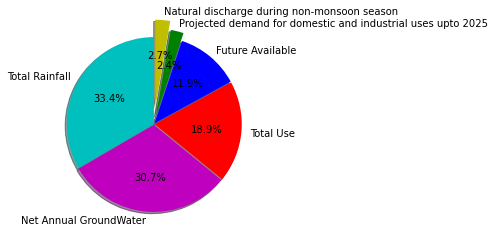

In [14]:
plt.pie(sizes,labels=labels,colors=cols,startangle=90,shadow=True,explode=(0,0.01,0.01,0.01,0.1,0.2),autopct='%1.1f%%')

In [15]:
label='EXCESS','MODERATED','SEMI-CRITICAL','CRITICAL'
sizes=[7,4,6,6]
cols = ['c','m','r','b']

([<matplotlib.patches.Wedge at 0x21ad5b88a30>,
 [Text(-0.9150062538795929, 0.6458819980160727, 'EXCESS'),
  Text(-0.700507679540436, -0.8610394827793171, 'MODERATED'),
  Text(0.7005075586159268, -0.8610395811587026, 'SEMI-CRITICAL'),
  Text(0.8185363453415478, 0.76445945043207, 'CRITICAL')],
 [Text(-0.5065213191119174, 0.3575418203303259, '30.4%'),
  Text(-0.3849636797474468, -0.4731838599057508, '17.4%'),
  Text(0.3849636132934372, -0.4731839139700978, '26.1%'),
  Text(0.4531183340283569, 0.4231829100606101, '26.1%')])

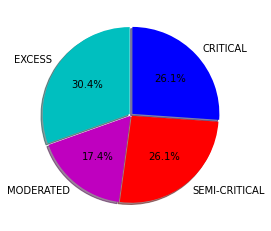

In [16]:
plt.pie(sizes,labels=label,colors=cols,startangle=90,shadow=True,explode=(0.02,0.01,0.01,0.02),autopct='%1.1f%%')

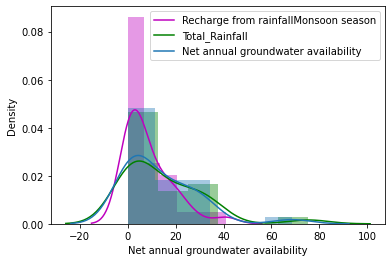

In [17]:
sb.distplot(new_data['Recharge from rainfallMonsoon season'],color='m')
sb.distplot(new_data['Total_Rainfall'],color='g')
sb.distplot(new_data['Net annual groundwater availability'])
plt.legend(['Recharge from rainfallMonsoon season','Total_Rainfall','Net annual groundwater availability'])

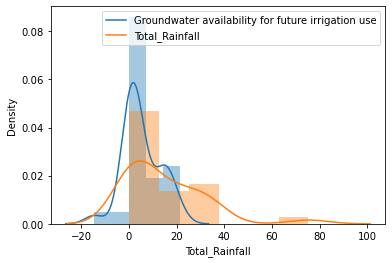

In [18]:
sb.distplot(new_data['Groundwater availability for future irrigation use'])
sb.distplot(new_data['Total_Rainfall'])
plt.legend(['Groundwater availability for future irrigation use','Total_Rainfall'])

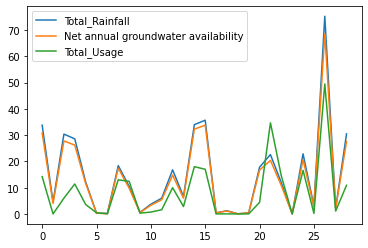

In [19]:
new_data["Total_Rainfall"].plot(kind='line')
new_data["Net annual groundwater availability"].plot()
new_data["Total_Usage"].plot()
plt.legend(['Total_Rainfall','Net annual groundwater availability','Total_Usage'])

In [20]:
from sklearn.tree import DecisionTreeClassifier
x=new_data.iloc[:,[5,6,7,10,11,12]]
Y=db.iloc[:,13]
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = .55, random_state=0)

In [21]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
X_scaled=ss.fit_transform(X)


In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled,Y,test_size = 0.33)

In [23]:
tree = DecisionTreeClassifier()
tree.fit(X_train, Y_train)

DecisionTreeClassifier()

In [24]:
tree.feature_importances_

array([0.        , 0.        , 0.24863686, 0.        , 0.        ,
       0.75136314])

In [25]:
print("accuracy on training set: %f" % tree.score(X_train, Y_train))
print("accuracy on test set: %f" % tree.score(X_test, Y_test))

accuracy on training set: 1.000000
accuracy on test set: 0.700000


In [26]:
predictions1 = tree.predict(X_test)
print(f'R^2 score: {r2_score(y_true=Y_test, y_pred=predictions1):.2f}')
print(f'MAE score: {mean_absolute_error(y_true=Y_test, y_pred=predictions1):.2f}')
print(f'EVS score: {explained_variance_score(y_true=Y_test, y_pred=predictions1):.2f}')

R^2 score: 0.32
MAE score: 0.60
EVS score: 0.52


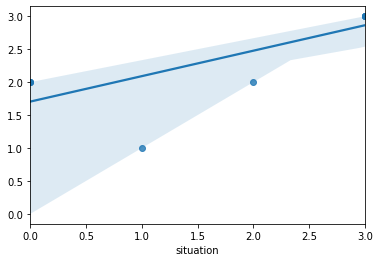

In [27]:
rp = sns.regplot(x=Y_test, y=predictions1)

In [28]:
tree.feature_importances_

array([0.        , 0.        , 0.24863686, 0.        , 0.        ,
       0.75136314])

In [29]:
features_names = new_data.columns
features_names

Index(['States', 'Recharge from rainfallMonsoon season',
       'Recharge from other sources',
       'Recharge from rainfallNon-monsoon season',
       'Recharge from other sources.1', 'Total_Rainfall',
       'Natural discharge during non-monsoon season',
       'Net annual groundwater availability', 'Irrigation',
       'Domestic and industrial uses', 'Total_Usage',
       'Projected demand for domestic and industrial uses upto 2025',
       'Groundwater availability for future irrigation use', 'situation',
       'EXCESS', 'MODERATED', 'SEMICRITICAL '],
      dtype='object')

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [31]:
x=new_data.iloc[:,[5,6,7,10,11,12]]
y=new_data.iloc[:,14]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.55, random_state=0)

In [33]:
random = RandomForestClassifier()
random.fit(X_train, y_train)

RandomForestClassifier()

In [34]:
print("accuracy on training set: %f" % random.score(X_train, y_train))
print("accuracy on test set: %f" % random.score(X_test, y_test))

accuracy on training set: 1.000000
accuracy on test set: 0.937500


In [35]:
predictions = random.predict(X_test)
print(f'R^2 score: {r2_score(y_true=y_test, y_pred=predictions):.2f}')
print(f'MAE score: {mean_absolute_error(y_true=y_test, y_pred=predictions):.2f}')
print(f'EVS score: {explained_variance_score(y_true=y_test, y_pred=predictions):.2f}')


R^2 score: 0.67
MAE score: 15.94
EVS score: 0.69


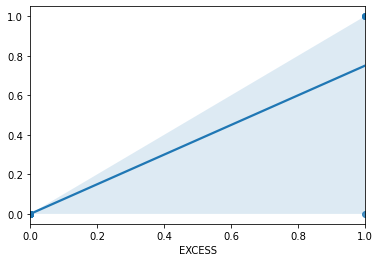

In [36]:
rp = sns.regplot(x=y_test, y=predictions)

In [37]:
X_scaled=ss.fit_transform(X)
xst,xste,yst,yste=train_test_split(X_scaled, y, test_size=0.55, random_state=0)

In [38]:
model = RandomForestClassifier()
model.fit(xst, yst)

RandomForestClassifier()

In [39]:
model.score(xste,yste)

0.9375

In [40]:
predictions = random.predict(xste)
print(f'R^2 score: {r2_score(y_true=yste, y_pred=predictions):.2f}')
print(f'MAE score: {mean_absolute_error(y_true=yste, y_pred=predictions):.2f}')
print(f'EVS score: {explained_variance_score(y_true=yste, y_pred=predictions):.2f}')

R^2 score: -0.33
MAE score: 63.75
EVS score: 0.00


In [41]:
from sklearn.pipeline import make_pipeline

In [42]:
from sklearn.preprocessing import StandardScaler

In [43]:
from sklearn.svm import SVC

In [44]:
clf = make_pipeline(StandardScaler(), SVC(gamma='auto'))

In [45]:
clf.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(gamma='auto'))])

In [46]:
print("Accuracy on training set:%f"%clf.score(X_train,y_train))

Accuracy on training set:1.000000


In [47]:
print("Accuracy on testing set:%f"%clf.score(X_test,y_test))

Accuracy on testing set:0.875000


In [48]:
predictions2 = clf.predict(X_test)
print(f'R^2 score: {r2_score(y_true=y_test, y_pred=predictions2):.2f}')
print(f'MAE score: {mean_absolute_error(y_true=y_test, y_pred=predictions2):.2f}')
print(f'EVS score: {explained_variance_score(y_true=y_test, y_pred=predictions2):.2f}')


R^2 score: 0.33
MAE score: 31.88
EVS score: 0.42


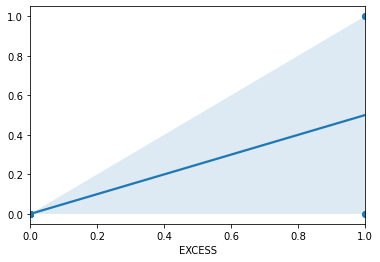

In [49]:
rp = sns.regplot(x=y_test, y=predictions2)

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
X=new_data.iloc[:,[5,6,7,10,11,12]]
Y=new_data.iloc[:,[13]]
X_tr, X_te, y_tr, y_te = train_test_split(X, Y, test_size=0.55, random_state=0)

In [51]:
random=RandomForestClassifier()
random.fit(X_tr,y_tr)

RandomForestClassifier()

In [52]:
random.predict(X_te)

array([0, 2, 3, 2, 3, 3, 3, 0, 3, 0, 2, 3, 2, 3, 3, 3], dtype=int64)

In [53]:
random.predict_proba(X_tr)

array([[0.72, 0.02, 0.24, 0.02],
       [0.  , 0.  , 0.  , 1.  ],
       [0.  , 0.  , 0.88, 0.12],
       [0.  , 0.  , 0.  , 1.  ],
       [0.  , 0.  , 0.  , 1.  ],
       [0.  , 0.  , 0.  , 1.  ],
       [0.01, 0.05, 0.91, 0.03],
       [0.1 , 0.64, 0.25, 0.01],
       [0.29, 0.01, 0.7 , 0.  ],
       [0.91, 0.03, 0.06, 0.  ],
       [0.05, 0.21, 0.16, 0.58],
       [0.76, 0.12, 0.12, 0.  ],
       [0.01, 0.04, 0.93, 0.02]])

In [54]:
random.predict_proba(X_te)

array([[0.62, 0.03, 0.33, 0.02],
       [0.01, 0.01, 0.92, 0.06],
       [0.  , 0.  , 0.  , 1.  ],
       [0.  , 0.08, 0.67, 0.25],
       [0.  , 0.04, 0.41, 0.55],
       [0.  , 0.  , 0.01, 0.99],
       [0.  , 0.  , 0.  , 1.  ],
       [0.88, 0.06, 0.04, 0.02],
       [0.  , 0.  , 0.  , 1.  ],
       [0.6 , 0.18, 0.22, 0.  ],
       [0.01, 0.02, 0.56, 0.41],
       [0.  , 0.  , 0.  , 1.  ],
       [0.06, 0.13, 0.49, 0.32],
       [0.  , 0.  , 0.  , 1.  ],
       [0.  , 0.04, 0.28, 0.68],
       [0.  , 0.01, 0.18, 0.81]])

In [55]:
target={'0':'EXCESS','1':'SEMICRITICAL','2':'MODERATED','3':'CRITICAL'}
pr=random.predict(X_te)
pr=list(pr)
st=[]
for i in pr:
    st.append(target[str(i)])
st

['EXCESS',
 'MODERATED',
 'CRITICAL',
 'MODERATED',
 'CRITICAL',
 'CRITICAL',
 'CRITICAL',
 'EXCESS',
 'CRITICAL',
 'EXCESS',
 'MODERATED',
 'CRITICAL',
 'MODERATED',
 'CRITICAL',
 'CRITICAL',
 'CRITICAL']